In [1]:
import sys
import os

# Add the parent directory to Python's search path
sys.path.append(os.path.abspath('..'))

In [2]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

def get_noise_model(p: float) -> NoiseModel:
    """Creates a noise model with depolarizing error probability p."""
    error_1q = depolarizing_error(p, 1)
    error_2q = depolarizing_error(p, 2)
    
    noise_model = NoiseModel()
    # Apply to all 1-qubit and 2-qubit gates
    noise_model.add_all_qubit_quantum_error(error_1q, ['u1', 'u2', 'u3', 'rx', 'ry', 'rz', 'h', 'x'])
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])
    return noise_model

In [3]:
# Define paths to files you've already generated
authentic_qr_path = "data/auth_demo.png" # Update this to your actual path
tampered_qr_path = "data/fixtures/fixture_01_data.png" # Update this to your actual path

In [4]:
import numpy as np
from quantum_qr.verifier import verify

# Test setup
noise_levels = [0.0, 0.01, 0.05, 0.1]
# Assume 'authentic_qr_path' and 'tampered_qr_path' are defined paths
results = {"authentic": [], "tampered": []}

for p in noise_levels:
    noise_model = get_noise_model(p)
    # Note: verify() needs to be able to accept a noise_model argument 
    # if you want to inject it directly! 
    # If not, you might need a small helper to inject the model into AerSimulator.
    print(f"Testing noise level p={p}...")
    
    # Run authentic
    res_auth = verify(authentic_qr_path, noise_model=noise_model) 
    results["authentic"].append(res_auth["p_zeros"])
    
    # Run tampered
    res_tamp = verify(tampered_qr_path, noise_model=noise_model)
    results["tampered"].append(res_tamp["p_zeros"])

Testing noise level p=0.0...
Testing noise level p=0.01...
Testing noise level p=0.05...
Testing noise level p=0.1...


Running noise sweep...
p=0.000 | Auth P(0): 0.00 | Tamp P(0): 0.00
p=0.011 | Auth P(0): 0.00 | Tamp P(0): 0.00
p=0.022 | Auth P(0): 0.00 | Tamp P(0): 0.00
p=0.033 | Auth P(0): 0.00 | Tamp P(0): 0.00
p=0.044 | Auth P(0): 0.00 | Tamp P(0): 0.00
p=0.056 | Auth P(0): 0.00 | Tamp P(0): 0.00
p=0.067 | Auth P(0): 0.00 | Tamp P(0): 0.00
p=0.078 | Auth P(0): 0.00 | Tamp P(0): 0.00
p=0.089 | Auth P(0): 0.00 | Tamp P(0): 0.00
p=0.100 | Auth P(0): 0.00 | Tamp P(0): 0.00

✅ Plot saved to data/noise_sweep.png


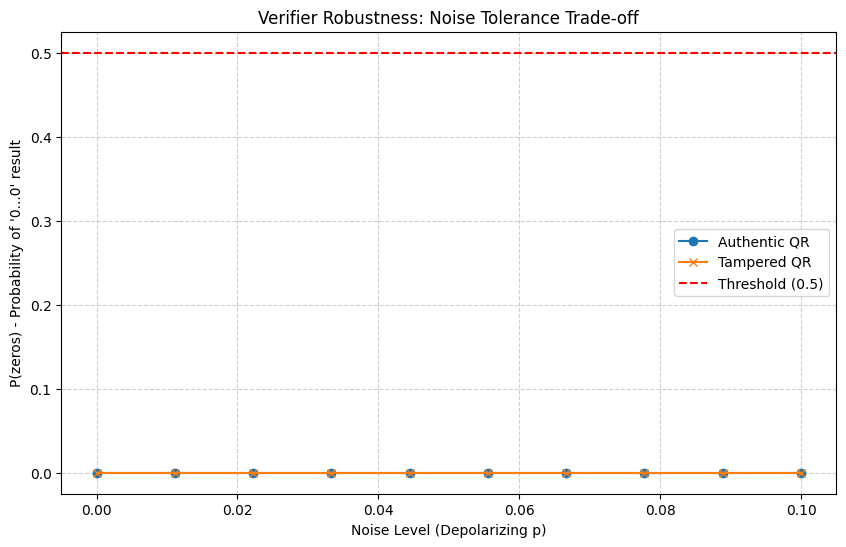

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer.noise import NoiseModel, depolarizing_error
from quantum_qr.verifier import verify

# 1. Helper to define the noise model
def get_noise_model(p: float) -> NoiseModel:
    error_1q = depolarizing_error(p, 1)
    error_2q = depolarizing_error(p, 2)
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(error_1q, ['u1', 'u2', 'u3', 'rx', 'ry', 'rz', 'h', 'x'])
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])
    return noise_model

# 2. Setup paths (Update these to match your file structure)
authentic_qr = "data/fixtures/fixture_00_baseline.png" 
tampered_qr = "data/fixtures/fixture_01_data.png"
threshold = 0.5
noise_levels = np.linspace(0, 0.1, 10)

# 3. Run the sweep
auth_p_zeros = []
tamp_p_zeros = []

print("Running noise sweep...")
for p in noise_levels:
    nm = get_noise_model(p)
    
    # Run authentic
    res_auth = verify(authentic_qr, noise_model=nm, accept_threshold=threshold)
    auth_p_zeros.append(res_auth.get("p_zeros", 0.0))
    
    # Run tampered
    res_tamp = verify(tampered_qr, noise_model=nm, accept_threshold=threshold)
    tamp_p_zeros.append(res_tamp.get("p_zeros", 0.0))
    print(f"p={p:.3f} | Auth P(0): {auth_p_zeros[-1]:.2f} | Tamp P(0): {tamp_p_zeros[-1]:.2f}")

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(noise_levels, auth_p_zeros, marker='o', label="Authentic QR")
plt.plot(noise_levels, tamp_p_zeros, marker='x', label="Tampered QR")
plt.axhline(y=threshold, color='r', linestyle='--', label=f"Threshold ({threshold})")

plt.xlabel("Noise Level (Depolarizing p)")
plt.ylabel("P(zeros) - Probability of '0...0' result")
plt.title("Verifier Robustness: Noise Tolerance Trade-off")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 5. Save the artifact
plt.savefig("../data/noise_sweep.png")
print("\n✅ Plot saved to data/noise_sweep.png")
plt.show()

In [5]:
from quantum_qr.evaluate import evaluate_corpus
from quantum_qr.viz import plot_confusion_matrix

# Run the evaluation
results = evaluate_corpus("../data/fixtures")

# Plot the matrix
plot_confusion_matrix(results, "../data/confusion_matrix_sim.png")

✅ Confusion matrix saved to: ../data/confusion_matrix_sim.png
